In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [6]:
weather_data = pd.read_csv("../data/clean/weather_clean.csv")

weather_data.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,showers_sum,wind_speed_10m_max,wind_gusts_10m_max,relative_humidity_2m_mean,cloud_cover_mean,sunshine_duration,shortwave_radiation_sum,city,month,year,season
0,2020-01-01,5.2,-1.0,2.8,0.6,0.6,0.0,12.2,22.7,97,99,0.00,1.57,Paris,1,2020,winter
1,2020-01-02,9.2,4.7,7.2,1.5,1.5,0.0,18.8,31.3,94,94,12730.83,2.36,Paris,1,2020,winter
2,2020-01-03,11.5,7.9,9.7,0.9,0.9,0.0,24.4,41.4,88,94,13199.25,2.18,Paris,1,2020,winter
3,2020-01-04,8.6,2.6,5.8,0.0,0.0,0.0,16.3,29.9,87,71,21947.97,4.16,Paris,1,2020,winter
4,2020-01-05,8.9,2.3,5.3,0.0,0.0,0.0,7.6,11.5,92,51,28800.00,3.69,Paris,1,2020,winter


In [7]:
X = weather_data[[
    "temperature_2m_mean",
    "precipitation_sum",
    "wind_gusts_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean"
]]

In [9]:
weather_data["hail_risk"] = (
    (weather_data["wind_gusts_10m_max"] > 60) &
    (weather_data["precipitation_sum"] > 10)
).astype(int)

In [34]:
weather_data["hail_risk"].value_counts(normalize=True)

hail_risk
0    0.986448
1    0.013552
Name: proportion, dtype: float64

In [38]:
weather_data.groupby("hail_risk").mean(numeric_only=True).T

hail_risk,0,1
temperature_2m_max,17.759631,15.045455
temperature_2m_min,9.518512,9.939394
temperature_2m_mean,13.555426,12.520202
precipitation_sum,1.941493,18.532323
rain_sum,1.916694,18.531313
showers_sum,0.000000,0.000000
wind_speed_10m_max,19.846406,37.014141
wind_gusts_10m_max,38.320677,72.093939
relative_humidity_2m_mean,74.227033,83.656566
cloud_cover_mean,56.846794,89.595960


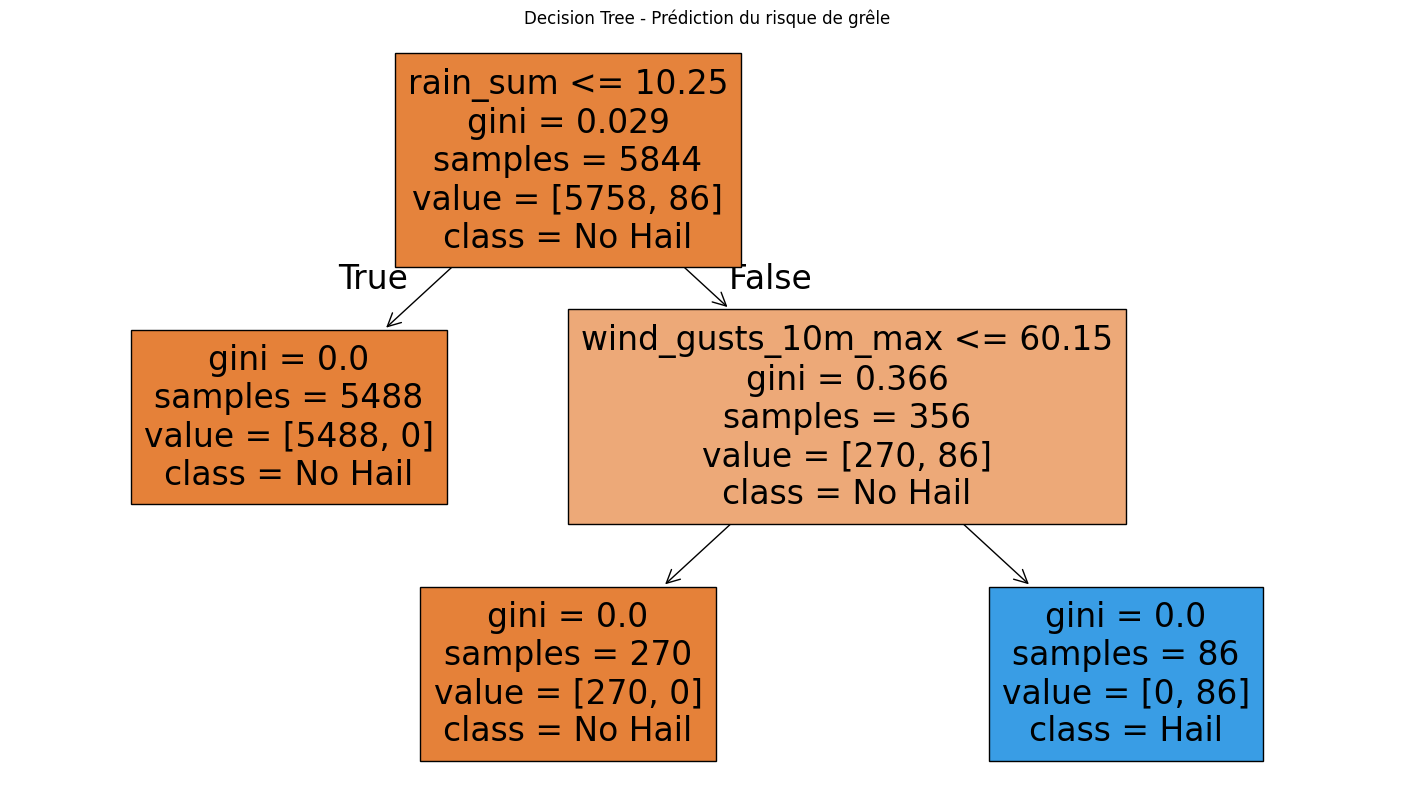

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Charger les données
weather_data = pd.read_csv("../data/clean/weather_clean.csv")

# Recréer la variable cible hail_risk
weather_data["hail_risk"] = (
    (weather_data["wind_gusts_10m_max"] > 60) &
    (weather_data["precipitation_sum"] > 10)
).astype(int)

# Définir y
y = weather_data["hail_risk"]

# Prendre toutes les colonnes numériques sauf hail_risk
X = weather_data.select_dtypes(include="number").drop(columns=["hail_risk"])

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Modèle Decision Tree
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Plot de l'arbre
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Hail","Hail"],
    filled=True
)

plt.title("Decision Tree - Prédiction du risque de grêle")

plt.show()

In [43]:
weather_data.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,showers_sum,wind_speed_10m_max,wind_gusts_10m_max,relative_humidity_2m_mean,cloud_cover_mean,sunshine_duration,shortwave_radiation_sum,city,month,year,season,hail_risk
0,2020-01-01,5.2,-1.0,2.8,0.6,0.6,0.0,12.2,22.7,97,99,0.00,1.57,Paris,1,2020,winter,0
1,2020-01-02,9.2,4.7,7.2,1.5,1.5,0.0,18.8,31.3,94,94,12730.83,2.36,Paris,1,2020,winter,0
2,2020-01-03,11.5,7.9,9.7,0.9,0.9,0.0,24.4,41.4,88,94,13199.25,2.18,Paris,1,2020,winter,0
3,2020-01-04,8.6,2.6,5.8,0.0,0.0,0.0,16.3,29.9,87,71,21947.97,4.16,Paris,1,2020,winter,0
4,2020-01-05,8.9,2.3,5.3,0.0,0.0,0.0,7.6,11.5,92,51,28800.00,3.69,Paris,1,2020,winter,0


1 predire rain_sum sans la deuxieme 
2 predire wind_gust sans la premiere variable
3 prise de decision ( si v(t) > 10 et w(t)> 60 alors risk de hail grele)

sarimax model

In [11]:
y = weather_data["hail_risk"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [15]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1448
           1       1.00      0.92      0.96        13

    accuracy                           1.00      1461
   macro avg       1.00      0.96      0.98      1461
weighted avg       1.00      1.00      1.00      1461



In [18]:
print(confusion_matrix(y_test, y_pred))

[[1448    0]
 [   1   12]]


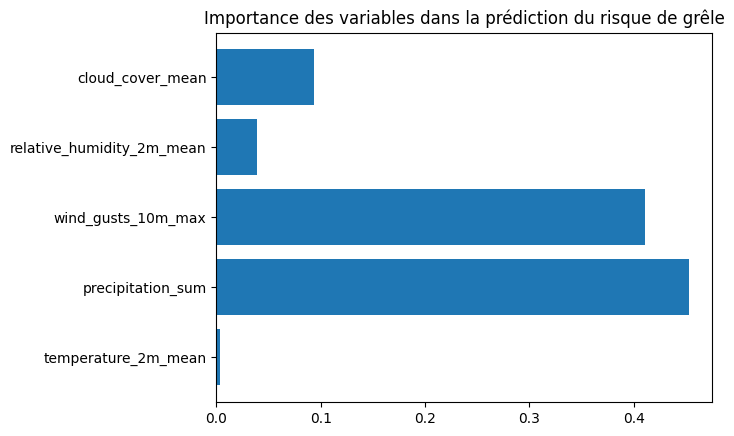

In [19]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)

plt.title("Importance des variables dans la prédiction du risque de grêle")

plt.show()

In [20]:
y_prob = model.predict_proba(X_test)[:,1]

In [21]:
from sklearn.metrics import roc_curve, auc

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

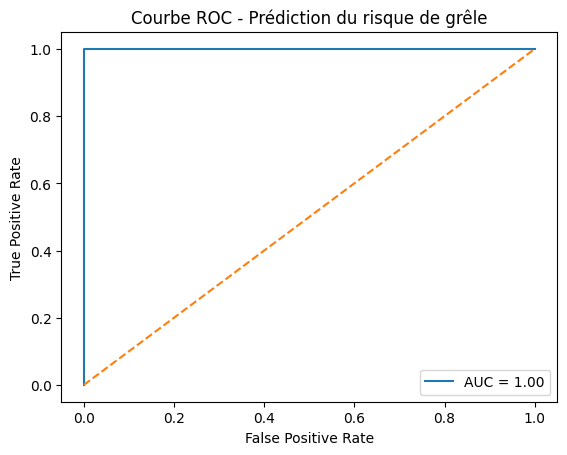

In [23]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Courbe ROC - Prédiction du risque de grêle")

plt.legend()

plt.show()

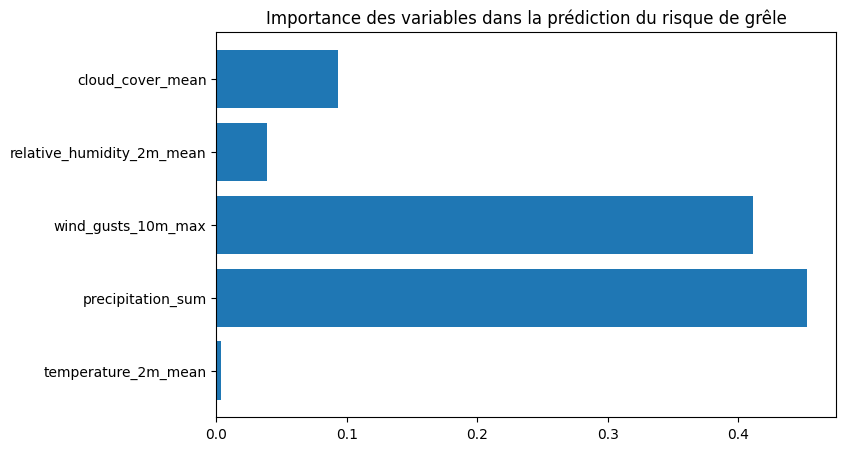

In [24]:
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)

plt.title("Importance des variables dans la prédiction du risque de grêle")

plt.show()

In [25]:
weather_data["prediction"] = model.predict(X)

In [26]:
weather_data["time"] = pd.to_datetime(weather_data["time"])

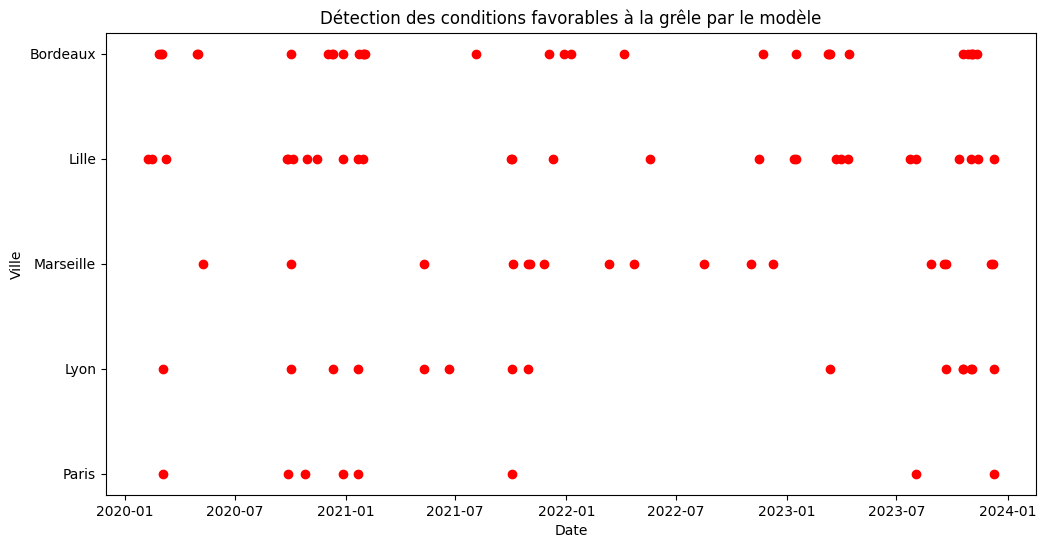

Points affichés : 98


In [31]:
import matplotlib.pyplot as plt

risk_days = weather_data[weather_data["prediction"] == 1]

plt.figure(figsize=(12,6))

plt.scatter(
    risk_days["time"],
    risk_days["city"],
    color="red"
)

plt.title("Détection des conditions favorables à la grêle par le modèle")

plt.xlabel("Date")
plt.ylabel("Ville")

plt.show()
print("Points affichés :", len(risk_days))

In [28]:
weather_data["prediction"] = model.predict(X)

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(weather_data["hail_risk"], weather_data["prediction"])

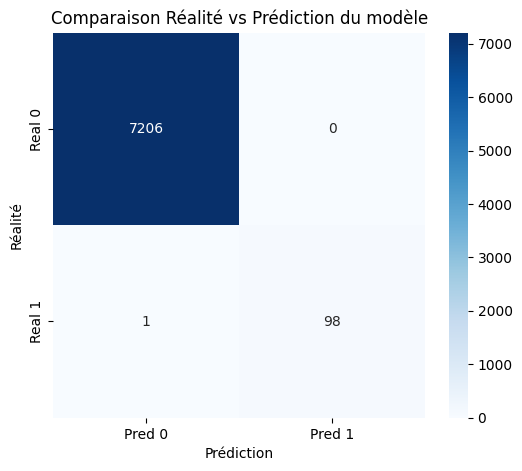

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0","Pred 1"],
    yticklabels=["Real 0","Real 1"]
)

plt.title("Comparaison Réalité vs Prédiction du modèle")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")

plt.show()